# Lesson 10: Multi-Tube Design Case Study

This final notebook is a capstone case study that uses ideas from every
previous lesson. We design a single strand `S` that behaves **differently
depending on what else is in the tube**: folded into its own hairpin
(lesson 4's target structure) when alone, but rearranged into a full duplex
with a partner strand `Q` when `Q` is present (lesson 9's multi-strand
design). The trick is `tube_design` accepting *multiple* `TargetTube`s that
share the same domains but specify **different on-target structures** -
the optimizer must find one sequence that satisfies both contexts at once.

**By the end of this notebook you will be able to:**

- Design a single set of domains that must satisfy *different* on-target
  structures in *different* tubes, by passing multiple `TargetTube`s to
  `tube_design`.
- Build a full **post-design verification dashboard**: re-run
  `tube_analysis` (lesson 5) in each tube context, check MFE structures
  (lesson 1-2), concentrations/fractions (lesson 5), and per-nucleotide
  defect (lesson 4) for the designed sequence.
- Recognize this "ON in one tube, OFF in another" pattern as the basis of
  conditional/triggered nucleic-acid devices (toehold switches, strand
  displacement, conditional probes).

**Prerequisites:** the whole series, especially
[`04_defect_analysis.ipynb`](04_defect_analysis.ipynb),
[`05_basic_tube_analysis.ipynb`](05_basic_tube_analysis.ipynb), and
[`07_intro_design.ipynb`](07_intro_design.ipynb)-[`09_tube_design.ipynb`](09_tube_design.ipynb).


## Introduction: one sequence, two contexts

Every design lesson so far has optimized a domain against the contents of
**one** `TargetTube`. But `tube_design` accepts a *list* of tubes:

```python
tube_design(tubes=[tube_alone, tube_with_partner], model=model)
```

If the same `Domain` objects appear in `TargetComplex`es belonging to both
tubes - but with **different target structures** - the optimizer searches
for a single sequence assignment that scores well in *both* contexts
simultaneously. That's exactly the behavior of a **conditional switch**:

- **Tube "alone"**: only strand `S` is present. Target: `S` folds into its
  own hairpin.
- **Tube "with partner"**: strands `S` and `Q` are both present. Target: `S`
  and `Q` form a full intermolecular duplex instead - `S`'s hairpin becomes
  an *off-target* in this tube.

We'll let `Q` be the reverse complement of `S` (`Q = ~S`, lesson 8's `~`
operator), so the same base-pairing potential that forms `S`'s hairpin stem
can instead be redirected into a longer, more stable `S`-`Q` duplex when `Q`
is available. After designing, we verify with `tube_analysis` in both
contexts - the same closing-the-loop pattern from lessons 7-9, now applied
twice.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import forgi.graph.bulge_graph as fgb
import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


def find_conc(conc_dict, *strands):
    '''Look up the equilibrium concentration of the complex containing exactly these strands.'''
    names = sorted(s.name for s in strands)
    for cx, val in conc_dict.items():
        if sorted(s.name for s in cx.strands) == names:
            return val
    return 0.0


def plot_structure(sequence, structure, ax, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 8}, backbone_kwargs={"linewidth": 2})
    ax.set_title(title)
    ax.set_axis_off()


def per_nt_defect(structure, pairs):
    '''Per-nucleotide defect d_i = 1 - P(target pairing at i), from lesson 4.'''
    n = len(structure)
    partner = [-1] * n
    stack = []
    for i, ch in enumerate(structure):
        if ch == "(":
            stack.append(i)
        elif ch == ")":
            j = stack.pop()
            partner[i] = j
            partner[j] = i

    d = np.zeros(n)
    for i in range(n):
        if partner[i] == -1:
            d[i] = 1 - pairs[i, i]
        else:
            d[i] = 1 - pairs[i, partner[i]]
    return d


## Theory: shared domains, different on-targets

Recall from lesson 9: a `TargetTube`'s `on_targets` dict maps
`TargetComplex -> concentration`, and `off_targets=SetSpec(max_size=...)`
penalizes any other complex up to that size. Nothing in this machinery
requires the *same* domains to play the same role in every tube - a domain
can be part of one `TargetComplex` in tube A and a *different*
`TargetComplex` in tube B.

`tube_design` minimizes a combined objective across **all** tubes passed to
it. For our switch:

- In `tube_alone = TargetTube(on_targets={c_hairpin: 1e-6}, ...)`, the
  objective rewards sequences where `S`'s own hairpin (`c_hairpin`, built
  from domain `dS` alone) is the dominant species.
- In `tube_duplex = TargetTube(on_targets={c_duplex: 1e-6}, ...)`, the
  objective rewards sequences where the `S`-`Q` duplex (`c_duplex`, built
  from `dS` and `dQ = ~dS`) dominates instead.

Both tubes reference `dS` (directly or via its complement `dQ`), so
`tube_design(tubes=[tube_alone, tube_duplex], model=model)` must find **one**
sequence for `dS` that satisfies both - i.e., a sequence whose intramolecular
hairpin is favorable enough to dominate when `S` is alone, but whose
intermolecular pairing with `Q` is *more* favorable still, so it wins when
`Q` is added.


## Worked example: designing a context-dependent switch

`S` is a 16-nt domain. Alone, its target structure is a hairpin with a 6-bp
stem and a 4-nt loop (`((((((....))))))`). `Q = ~S` is `S`'s reverse
complement (lesson 8), and the `S`-`Q` target structure is a fully paired
16-bp duplex.


In [2]:
dS = Domain("N16", name="dS")
dQ = ~dS

strand_S = TargetStrand([dS], name="S")
strand_Q = TargetStrand([dQ], name="Q")

hairpin_structure = "((((((....))))))"
duplex_structure = "(" * 16 + "+" + ")" * 16

c_hairpin = TargetComplex([strand_S], hairpin_structure, name="c_hairpin")
c_duplex = TargetComplex([strand_S, strand_Q], duplex_structure, name="c_duplex")

tube_alone = TargetTube(on_targets={c_hairpin: 1e-6}, off_targets=SetSpec(max_size=2), name="alone_tube")
tube_duplex = TargetTube(on_targets={c_duplex: 1e-6}, off_targets=SetSpec(max_size=2), name="duplex_tube")

switch_results = tube_design(tubes=[tube_alone, tube_duplex], model=model).run(trials=3)
best_switch = min(switch_results, key=lambda r: r.ensemble_defect)
print(f"best ensemble defect: {best_switch.ensemble_defect:.5f}")

seq_S = str(best_switch.domains[dS])
seq_Q = str(best_switch.domains[dQ])
print("S:", seq_S)
print("Q:", seq_Q)


best ensemble defect: 0.00841
S: GGUAGGGUCUCCUACC
Q: GGUAGGAGACCCUACC


## Verification dashboard, part 1: `S` alone

Close the loop (lessons 7-9): build a real `Strand` from the designed
sequence, put it in a `Tube` by itself, and run `tube_analysis` (lesson 5).
We expect `S` to fold into its hairpin and dominate the tube.


In [3]:
S = Strand(seq_S, name="S")
Q = Strand(seq_Q, name="Q")

tube1 = Tube(strands={S: 1e-6}, complexes=SetSpec(max_size=2), name="alone_tube")
result1 = tube_analysis(tubes=[tube1], model=model, compute=["pfunc", "mfe", "pairs"])
cc1 = result1[tube1].complex_concentrations

S_alone_fraction = find_conc(cc1, S) / 1e-6
print(f"S monomer fraction: {S_alone_fraction:.4f}")

for cx in cc1:
    if cx.strands == (S,):
        mfe1 = str(result1[cx].mfe[0].structure)
        pairs1 = np.array(result1[cx].pairs.to_array())
print("MFE structure of S alone:", mfe1)
print("matches design target:   ", hairpin_structure, mfe1 == hairpin_structure)


S monomer fraction: 0.9984
MFE structure of S alone: ((((((....))))))
matches design target:    ((((((....)))))) True


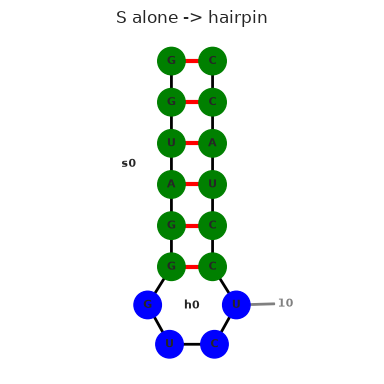

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_structure(seq_S, mfe1, ax, "S alone -> hairpin")
fig.tight_layout()
plt.show()


## Verification dashboard, part 2: `S` with `Q` present

Now put `S` and `Q` together in a tube at equal concentration and re-run
`tube_analysis`. We expect the `S`-`Q` duplex to dominate instead, with `S`'s
own hairpin suppressed as an off-target.


In [5]:
tube2 = Tube(strands={S: 1e-6, Q: 1e-6}, complexes=SetSpec(max_size=2), name="duplex_tube")
result2 = tube_analysis(tubes=[tube2], model=model, compute=["pfunc", "mfe", "pairs"])
cc2 = result2[tube2].complex_concentrations

SQ_duplex_fraction = find_conc(cc2, S, Q) / 1e-6
S_monomer_with_Q = find_conc(cc2, S) / 1e-6
Q_monomer_with_Q = find_conc(cc2, Q) / 1e-6

print(f"S+Q duplex fraction:        {SQ_duplex_fraction:.4f}")
print(f"S monomer fraction (w/ Q):  {S_monomer_with_Q:.4f}")
print(f"Q monomer fraction (w/ Q):  {Q_monomer_with_Q:.4f}")

for cx in cc2:
    if set(s.name for s in cx.strands) == {"S", "Q"}:
        mfe2 = str(result2[cx].mfe[0].structure)
print("MFE structure of S+Q:", mfe2)
print("matches design target:", duplex_structure, mfe2 == duplex_structure)


S+Q duplex fraction:        0.9985
S monomer fraction (w/ Q):  0.0015
Q monomer fraction (w/ Q):  0.0015
MFE structure of S+Q: ((((((((((((((((+))))))))))))))))
matches design target: ((((((((((((((((+)))))))))))))))) True


## Dashboard summary: the switch in action

Combine both tube contexts into a single bar chart - the species composition
flips depending on whether `Q` is present, exactly as designed.


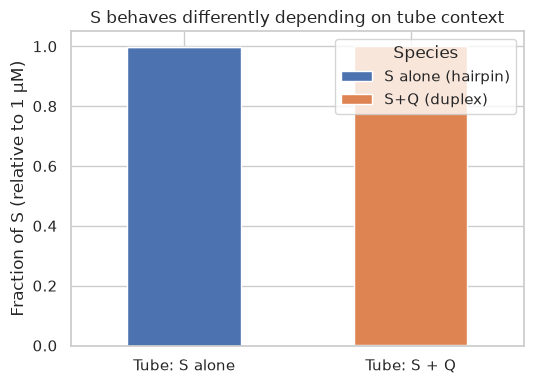

In [6]:
dashboard_df = pd.DataFrame({
    "S alone (hairpin)": [S_alone_fraction, S_monomer_with_Q],
    "S+Q (duplex)": [0.0, SQ_duplex_fraction],
}, index=["Tube: S alone", "Tube: S + Q"])

fig, ax = plt.subplots(figsize=(5.5, 4))
dashboard_df.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Fraction of S (relative to 1 µM)")
ax.set_ylim(0, 1.05)
ax.set_title("S behaves differently depending on tube context")
ax.legend(title="Species")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()


**Interpretation.** In the "S alone" tube, essentially all of `S` is folded
into its own hairpin (blue). Adding `Q` flips the outcome: essentially all of
`S` is now found in the `S`-`Q` duplex (orange), and the hairpin fraction
collapses to nearly zero. The *same designed sequence* `S` produces two
different structural outcomes purely as a function of what else is in the
tube - the defining feature of a conditional/triggered device.


## Per-nucleotide defect (lesson 4 callback)

Finally, revisit lesson 4's per-nucleotide defect profile for `S`'s hairpin
target, using the pair-probability matrix from the "alone" tube analysis.
This tells us *where* (if anywhere) the design is least confident about
matching the target hairpin.


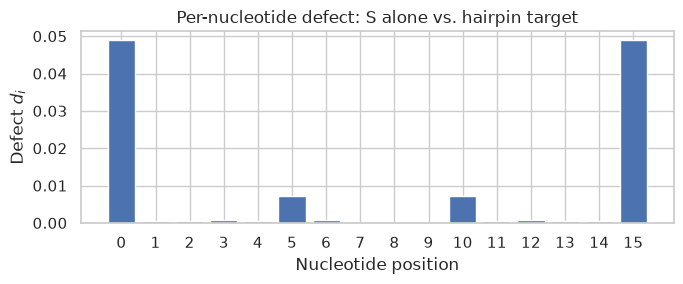

overall normalized defect (S alone, hairpin target): 0.00739


In [7]:
d_hairpin = per_nt_defect(hairpin_structure, pairs1)

fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#C44E52" if v > 0.05 else "#4C72B0" for v in d_hairpin]
ax.bar(range(len(d_hairpin)), d_hairpin, color=colors)
ax.set_xlabel("Nucleotide position")
ax.set_ylabel("Defect $d_i$")
ax.set_title("Per-nucleotide defect: S alone vs. hairpin target")
ax.set_xticks(range(len(d_hairpin)))
fig.tight_layout()
plt.show()

print(f"overall normalized defect (S alone, hairpin target): {d_hairpin.mean():.5f}")


## Best practices and common pitfalls

- **Multi-tube design scales the search space, not just the runtime.** Each
  additional tube adds more on/off-target complexes that must be tracked
  simultaneously - start from a working single-tube design (lessons 7-8)
  before adding a second tube with conflicting requirements.
- **Shared domains are the mechanism, not a side effect.** A sequence can
  only behave differently across tubes if the *same* designed domain (here
  `dS`, indirectly via `dQ = ~dS`) actually appears in the on-targets of
  every tube. If each tube used completely independent domains, there would
  be nothing forcing a trade-off - and nothing to verify.
- **Always verify every tube context separately**, exactly as in this
  dashboard. A multi-tube design can satisfy the *combined* objective while
  being mediocre in any single tube - check `tube_analysis` per tube, not
  just the overall `ensemble_defect`.
- **This pattern generalizes directly to real conditional devices**:
  toehold switches, strand-displacement reporters, and aptamer-based sensors
  all rely on one sequence whose preferred structure depends on which other
  strands (or small molecules) are present - precisely the "different
  on-targets in different tubes" idea used here.


## Summary and series wrap-up

In this notebook you:

1. Designed a single domain `dS` to satisfy **two different on-target
   structures** in **two different tubes**, by passing both `TargetTube`s to
   one `tube_design` call.
2. Built a full **verification dashboard**: re-analyzed the designed
   sequence with `tube_analysis` in each tube context, checked MFE
   structures against the design targets, and visualized the resulting
   species fractions.
3. Revisited lesson 4's per-nucleotide defect profile as a final design
   diagnostic.

This completes the 10-lesson NUPACK series - from a single complex's MFE
structure (lesson 1), through ensembles and probabilities (lessons 2-4), tube
equilibrium (lessons 5-6), to sequence design with constraints and
orthogonality (lessons 7-9), and finally a context-dependent multi-tube
design (this notebook). Every analysis tool introduced along the way -
`complex_analysis`, `defect`, `tube_analysis`, and `tube_design` - reappears
here in the verification dashboard.


## Exercises

1. The hairpin stem is 6 bp and the full duplex is 16 bp. Try shortening the
   hairpin stem to 4 bp (loop of 8: `((((........))))`) while keeping the
   duplex at 16 bp. Does the design defect improve or worsen? Does the
   "switch" behavior in the dashboard become more or less pronounced?
2. Add a third tube, `tube_triplet`, containing `S`, `Q`, and a second copy
   of `Q` (i.e. `Tube(strands={S: 1e-6, Q: 2e-6}, ...)`), with the same
   `c_duplex` on-target. Does the extra `Q` change the equilibrium fractions
   much? What does that tell you about how much "excess" partner strand a
   real triggered device might tolerate?
